<a href="https://colab.research.google.com/github/sandhu176/student-performance-analysis/blob/main/student%20performance%20analysis%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:

    df = pd.read_excel('/content/student_performance.csv.xlsx')
    df.copy()


,student_id,gender,age,parent_education,lunch,test_prep_course,study_hours_per_week,absences,math_score,reading_score,writing_score,passed
0,1,female,15,bachelor's degree,standard,completed,10,2,72,72,74,1
1,2,female,16,some college,standard,completed,8,3,69,90,88,1
2,3,female,17,master's degree,standard,none,5,4,90,95,93,1
3,4,male,15,associate's degree,free/reduced,none,4,6,47,57,44,0
4,5,male,16,some college,standard,none,6,5,76,78,75,1
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,female,17,bachelor's degree,free/reduced,none,4,7,47,55,50,0
96,97,male,15,master's degree,standard,completed,11,1,85,87,86,1
97,98,female,16,some high school,standard,none,6,5,62,67,64,1
98,99,male,17,some college,free/reduced,none,3,9,40,43,39,0


In [ ]:
df.shape

(100, 12)

In [ ]:
df.columns

Index(['student_id', 'gender', 'age', 'parent_education', 'lunch',
       'test_prep_course', 'study_hours_per_week', 'absences', 'math_score',
       'reading_score', 'writing_score', 'passed'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   student_id            100 non-null    int64 
 1   gender                100 non-null    object
 2   age                   100 non-null    int64 
 3   parent_education      100 non-null    object
 4   lunch                 100 non-null    object
 5   test_prep_course      100 non-null    object
 6   study_hours_per_week  100 non-null    int64 
 7   absences              100 non-null    int64 
 8   math_score            100 non-null    int64 
 9   reading_score         100 non-null    int64 
 10  writing_score         100 non-null    int64 
 11  passed                100 non-null    int64 
dtypes: int64(8), object(4)
memory usage: 9.5+ KB


In [ ]:
df.isnull().sum()

,0
student_id,0
gender,0
age,0
parent_education,0
lunch,0
test_prep_course,0
study_hours_per_week,0
absences,0
math_score,0
reading_score,0


In [ ]:



df.describe()

,student_id,age,study_hours_per_week,absences,math_score,reading_score,writing_score,passed
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,15.990000,7.010000,4.380000,63.490000,67.220000,64.640000,0.690000
std,29.011492,0.822598,3.089556,3.240464,19.537322,19.317433,20.444317,0.464823
min,1.000000,15.000000,2.000000,0.000000,26.000000,28.000000,24.000000,0.000000
25%,25.750000,15.000000,4.000000,2.000000,46.750000,53.750000,47.000000,0.000000
50%,50.500000,16.000000,7.000000,3.000000,67.500000,69.500000,68.500000,1.000000
75%,75.250000,17.000000,9.250000,7.000000,78.250000,82.250000,80.250000,1.000000
max,100.000000,17.000000,13.000000,12.000000,97.000000,98.000000,97.000000,1.000000


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
le = LabelEncoder()
for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = le.fit_transform(df[col])


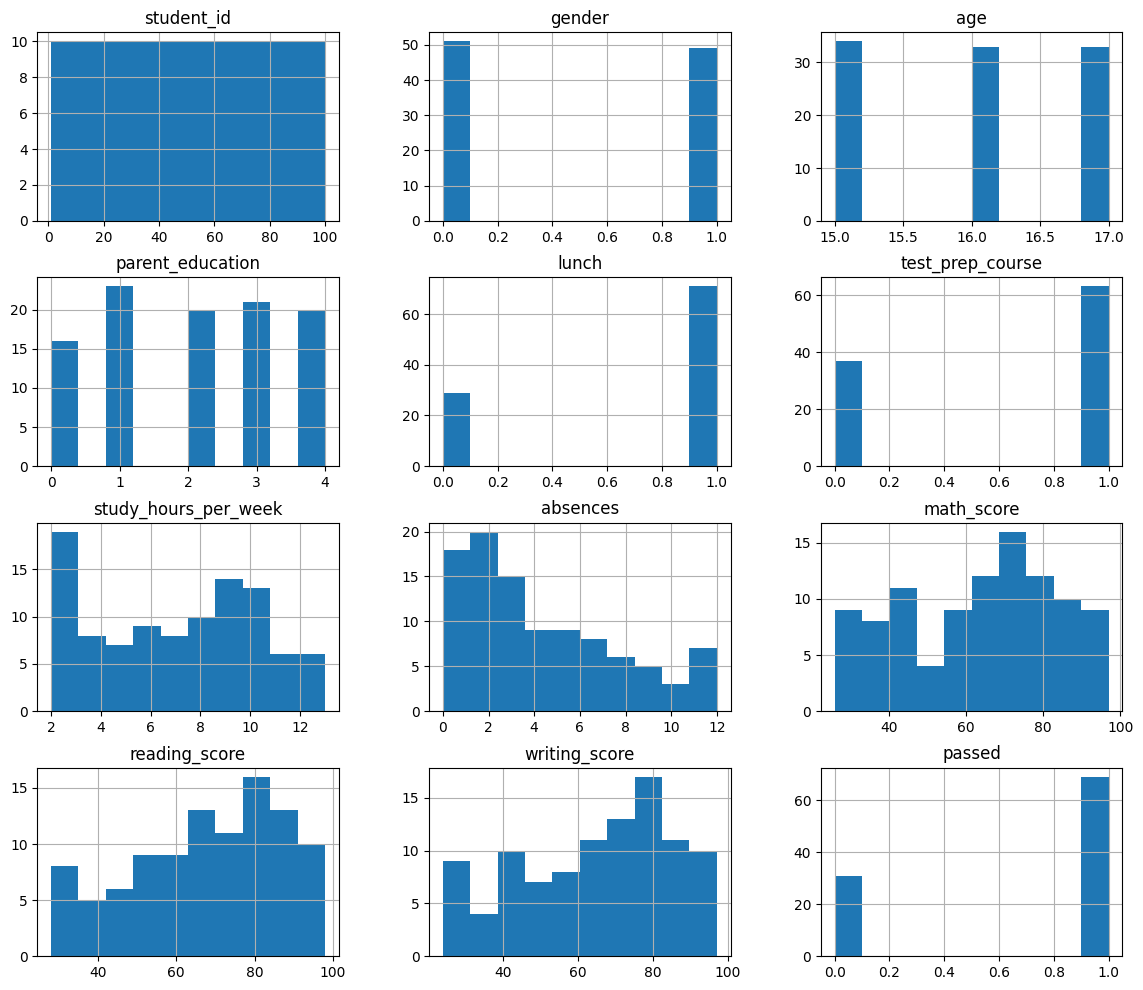

In [ ]:
df.hist(figsize=(14,12))
plt.show()






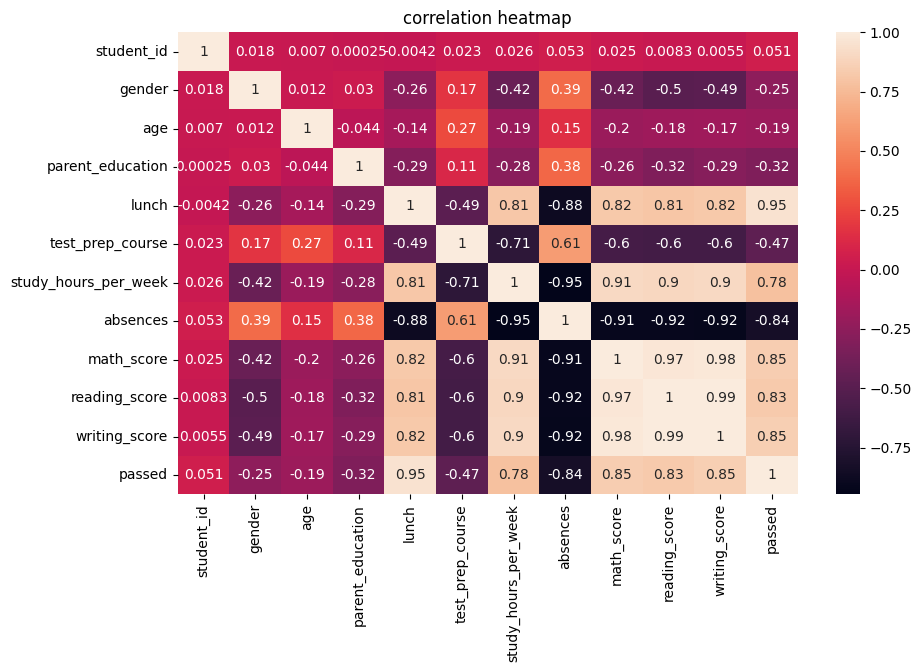

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("correlation heatmap")
plt.show()

In [ ]:
target_column = df.columns[-1]
X = df.drop(target_column, axis=1)
y = df[target_column]

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
models = {
     "Linear Regression": LinearRegression(),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forets":RandomForestRegressor(n_estimators=100)
}
trained_models ={}

for name, model in models.items():
  model.fit(X_train, y_train)
  trained_models[name] = model


In [ ]:
results = {}

for name, model in models.items():
  y_pred = model.predict(X_test)

  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  results[name] = {"MAE": mae, "R2": r2}

  print (f"\n{name}")
  print("MAE:", mae)
  print("R2 Score:", r2)


Linear Regression
MAE: 0.07937187582573113
R2 Score: 0.9425184081504909

Decision Tree
MAE: 0.0
R2 Score: 1.0

Random Forets
MAE: 0.019999999999999997
R2 Score: 0.9838571428571429


In [ ]:
best_model_name = max(results, key=lambda x: results[x]['R2'])
print("\nBest Model:",best_model_name)


Best Model: Decision Tree


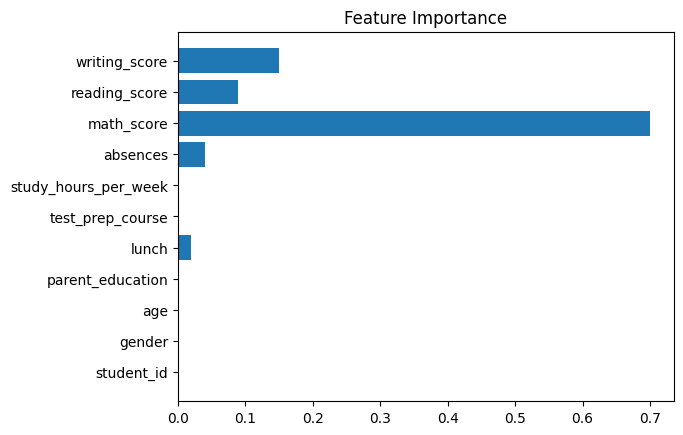

In [ ]:
if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_
        feature_names = X.columns

        plt.figure()
        plt.barh(feature_names, importance)
        plt.title("Feature Importance")
        plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_original_temp = pd.read_excel('/content/student_performance.csv.xlsx')
label_encoders_map = {}

categorical_columns_original = [col for col in df_original_temp.columns if df_original_temp[col].dtype == 'object']

for col_name in categorical_columns_original:
    le_temp = LabelEncoder()
    le_temp.fit(df_original_temp[col_name].astype(str))
    label_encoders_map[col_name] = le_temp


print("\nEnter values for prediction:")

input_data = []
for col in X.columns:
    if col in label_encoders_map:
        le_current = label_encoders_map[col]
        valid_inputs = ', '.join([str(s) for s in le_current.classes_])
        while True:
            user_input_str = input(f"{col} (choose from {valid_inputs}): ").strip().lower()
            if user_input_str in le_current.classes_:
                val = le_current.transform([user_input_str])[0]
                break
            else:
                print(f"Invalid input. Please choose from: {valid_inputs}")
    else:
        while True:
            try:
                val = float(input(f"{col}: "))
                break
            except ValueError:
                print("Invalid input. Please enter a number.")
    input_data.append(val)

input_array = np.array(input_data).reshape(1, -1)
input_scaled = scaler.transform(input_array)

model = trained_models[best_model_name]

prediction = model.predict(input_scaled)
print("\nPredicted Score:", prediction[0])



Enter values for prediction:
student_id: 
Invalid input. Please enter a number.
student_id: 
Invalid input. Please enter a number.
student_id: 
Invalid input. Please enter a number.
student_id: 3
gender (choose from female, male): male
age: 28
parent_education (choose from associate's degree, bachelor's degree, master's degree, some college, some high school): masters degree
Invalid input. Please choose from: associate's degree, bachelor's degree, master's degree, some college, some high school
parent_education (choose from associate's degree, bachelor's degree, master's degree, some college, some high school): master's degree
lunch (choose from free/reduced, standard): standart
Invalid input. Please choose from: free/reduced, standard
lunch (choose from free/reduced, standard): standard
test_prep_course (choose from completed, none): none
study_hours_per_week: 7
absences: 5
math_score: 78
reading_score: 79
writing_score: 80

Predicted Score: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


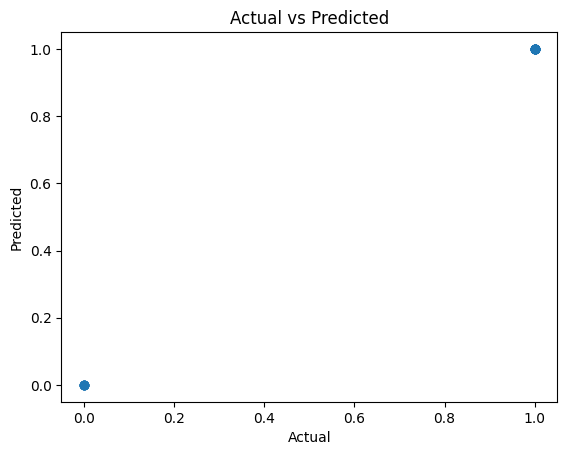

In [ ]:
def plot_predictions(model, X_test, y_test):
    y_pred = model.predict(X_test)

    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Actual vs Predicted")
    plt.show()

plot_predictions(trained_models[best_model_name], X_test,y_test)

